## Pretraining the Text Autoencoder on a custom dataset

In [1]:
# ── Pull the project from GitHub and make `src` importable in Colab ──
import os, sys, subprocess

REPO_URL = "https://github.com/arinzefu/Cross-Modal-Temporal-Prediction-with-RoBERTa-GPT-2-and-CLIP-Guided-Diffusion.git"
REPO_DIR = "/content/Cross-Modal-Temporal-Prediction-with-RoBERTa-GPT-2-and-CLIP-Guided-Diffusion"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)          # so `from src.models... import ...` resolves

req = os.path.join(REPO_DIR, "requirements.txt")
if os.path.exists(req):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", req], check=True)

print("Repo ready at:", REPO_DIR)
print("src/:", os.listdir(os.path.join(REPO_DIR, "src")))

Repo ready at: /content/Cross-Modal-Temporal-Prediction-with-RoBERTa-GPT-2-and-CLIP-Guided-Diffusion
src/: ['utils', 'models', 'training']


In [2]:
!pip install torchinfo
!pip install clip
!pip install evaluate
!pip install rouge_score
!pip install nltk

  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-0.2.0-py3-none-any.whl size=6989 sha256=f182d8499d654d0f1b290bae2ead12c6b9ba00d9203d2ba058dfe2ba658bd4a0
  Stored in directory: /root/.cache/pip/wheels/6c/fd/54/9d4e15cf829b871199a7cd3597e869a514d1624a0a43076896
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=7a8cc98f577e7f7991d6fa03c1a952c7aa0da566e65e51afea63a4f5d1fdcbd9
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [3]:
# @title Importing the necessary libraries

import torch
import torch.nn as nn
import torch.nn.functional as F
import clip
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import numpy as np
import os
from nltk.translate.bleu_score import sentence_bleu
import json
import pandas as pd
from torchinfo import summary
from transformers import CLIPProcessor, CLIPModel, RobertaModel, RobertaTokenizer, GPT2Tokenizer
import evaluate
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import tqdm
from datasets.fingerprint import random
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms.functional as FT
import math
from transformers import BertTokenizer
import gc
import random

from typing import Dict, Any, List, Optional, Tuple
import textwrap
from tqdm import tqdm
from src.utils.helper import parse_gdi_text, save_checkpoint_to_drive, load_checkpoint_from_drive, emb_dim, latent_dim, num_layers, max_seq_len, batch_size, dropout

# **Chapter 1: The data preparation**


---



## 1.1 Loading and saving data

In [4]:


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We need to define a couple of functions to make our life easier. Feel free to tweak those functions:

In [5]:

emb_dim = emb_dim
latent_dim = latent_dim
num_layers = num_layers
max_seq_len = max_seq_len
batch_size = batch_size
dropout = dropout

from transformers import get_cosine_schedule_with_warmup

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Now we load dataset from HuggingFace:

In [6]:
# @title Loading the dataset
from datasets import load_dataset

train_dataset = load_dataset("qwedsacf/story-generation")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/759 [00:00<?, ?B/s]

data/train-00000-of-00001-03560cf8eb66ee(…):   0%|          | 0.00/213M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/427223 [00:00<?, ? examples/s]

In [7]:
# @title CoT improvements toggles (added)



USE_FRAME_AWARE_GROUNDING = True
USE_CONTRASTIVE_ROI = True
USE_ENTITY_POOLING = True
USE_COT_TEXT = True


CONTRASTIVE_TAU = 0.07

In [8]:
from src.utils.helper import TextDataset

enc_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
dec_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
text_dataset = TextDataset(
    train_dataset['train'], enc_tokenizer, dec_tokenizer,
    max_len=max_seq_len, max_target_len=256, text_field="story",
)
text_dataloader = DataLoader(text_dataset, batch_size=batch_size, shuffle=True)
for batch in text_dataloader:
    print(batch["input_ids"].shape, batch["attention_mask"].shape, batch["labels"].shape)
    break

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

torch.Size([16, 120]) torch.Size([16, 120]) torch.Size([16, 256])


In [9]:

for batch in text_dataloader:
    print(batch["input_ids"].shape, batch["attention_mask"].shape)
    break

torch.Size([16, 120]) torch.Size([16, 120])


In [11]:
print(train_dataset['train'][0].keys())

dict_keys(['summary', 'story', 'source'])


## 3.1 Initialization and setup

In [12]:
# @title Initializing the Roberta model
from src.models.text_autoencoder import RobertaEncoder, TransformerDecoder, Seq2Seq, SinusoidalPositionalEncoding
torch.cuda.empty_cache()
gc.collect()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dec_tokenizer.pad_token = dec_tokenizer.eos_token      # GPT-2 has no pad token

text_autoencoder = Seq2Seq(
    encoder_name="roberta-base",
    decoder_name="gpt2",
    unfreeze_encoder_layers=6,
    enc_tokenizer=enc_tokenizer,
    dec_tokenizer=dec_tokenizer,
).to(device)

trainable = sum(p.numel() for p in text_autoencoder.parameters() if p.requires_grad)
total     = sum(p.numel() for p in text_autoencoder.parameters())
print(f"Trainable params: {trainable:,}")
print(f"Total params:     {total:,}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                                                 | Status     | 
----------------------------------------------------+------------+-
h.{0...11}.attn.bias                                | UNEXPECTED | 
transformer.h.{0...11}.crossattention.c_attn.weight | MISSING    | 
transformer.h.{0...11}.crossattention.c_proj.weight | MISSING    | 
transformer.h.{0...11}.crossattention.q_attn.weight | MISSING    | 
transformer.h.{0...11}.crossattention.c_proj.bias   | MISSING    | 
transformer.h.{0...11}.ln_cross_attn.weight         | MISSING    | 
transformer.h.{0...11}.crossattention.q_attn.bias   | MISSING    | 
transformer.h.{0...11}.crossattention.c_attn.bias   | MISSING    | 
transformer.h.{0...11}.ln_cross_attn.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Trainable params: 195,333,888
Total params:     277,452,288


In [13]:
enc_len = min(max_seq_len, 512)        # RoBERTa caps at 512
dec_len = 256                          # target length (match your max_target_len)

dummy_input  = torch.randint(0, enc_tokenizer.vocab_size, (batch_size, enc_len)).to(device)
dummy_mask   = torch.ones((batch_size, enc_len), dtype=torch.long).to(device)   # all valid
dummy_labels = torch.randint(0, dec_tokenizer.vocab_size, (batch_size, dec_len)).to(device)

print("===== RoBERTa2GPT2 Seq2Seq Summary =====")
summary(
    text_autoencoder,
    input_data=(dummy_input, dummy_mask, dummy_labels),   # input_ids, attention_mask, labels
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3,
)

===== RoBERTa2GPT2 Seq2Seq Summary =====


/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Layer (type:depth-idx)                                            Input Shape               Output Shape              Param #                   Trainable
Seq2Seq                                                           [16, 120]                 [16, 120, 768]            --                        Partial
├─EncoderDecoderModel: 1-1                                        --                        [16, 120, 768]            --                        Partial
│    └─RobertaModel: 2-1                                          --                        [16, 768]                 --                        Partial
│    │    └─RobertaEmbeddings: 3-1                                --                        [16, 120, 768]            (39,000,576)              False
│    │    └─RobertaEncoder: 3-2                                   [16, 120, 768]            [16, 120, 768]            85,054,464                Partial
│    │    └─RobertaPooler: 3-3                                    [16, 120, 768]        

## 3.2 Training loops

No checkpoint found on Drive – training from scratch.


Epoch 1/1: 100%|██████████| 26702/26702 [4:25:15<00:00,  1.68it/s, loss=3.4295, enc_lr=0.00e+00, dec_lr=0.00e+00]



Epoch 1
CE Loss    : 3.48892

  EPOCH 1 EVALUATION

REFERENCE:
She had, not so long ago, lived in the deep sea. Her lithe silver body pulling saltwater through her gills as she explored the dark depths, feeding on its bounty.

Now, she fought her way upstream in the clear, saltless water.

GENERATED:
T, the river below her was no more. She let out a slow yell as the water came back into view. She watched the wave slowly sink in. With the tide's power and pressure, she was able to swim back to shore without the help of the water or the currents. As the tide came in, the water became a thick, tattered line of water. The boat started to shake and the fish's tiny wings struggled to escape and even

Scores:
BLEU-4  : 0.0068
METEOR  : 0.2101
ROUGE-1 : 0.1676
ROUGE-2 : 0.0339
ROUGE-L : 0.1006

DIVERSITY TEST

[river_fish]
PROMPT : The fish swam against the powerful river current beneath bright morning sunlight.
OUTPUT : , the water had gotten cold and the fish had been dead for the past five

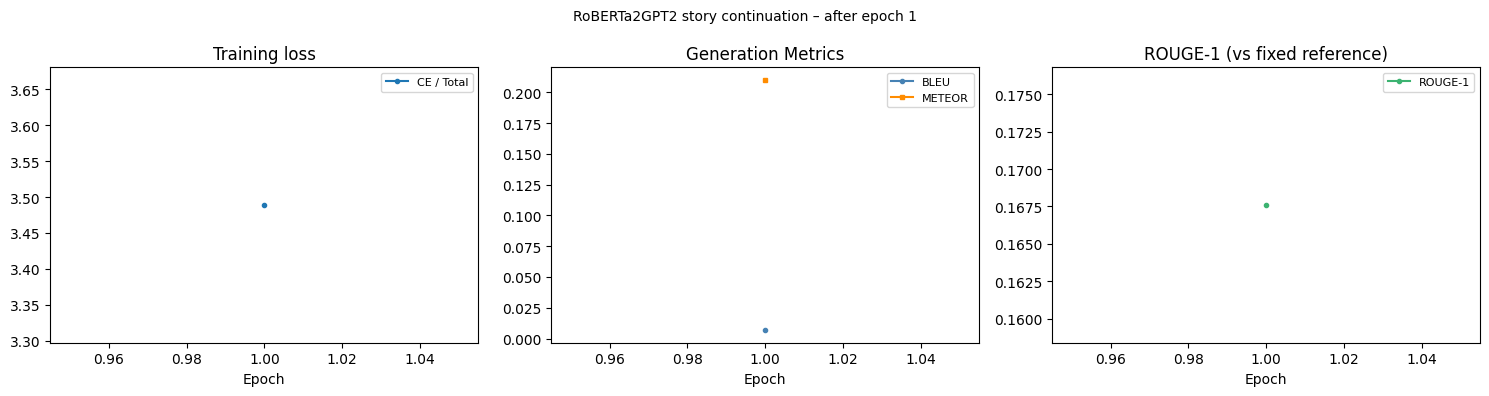


✓ Training complete.


In [15]:
from src.training.train_text import (
    ContrastiveDiversityLoss,
    EarlyStopping,
    build_optimizer,
    build_scheduler,
    train_text_autoencoder,
)

# =========================================================
# FIXED EVALUATION PROMPTS
# =========================================================
EVAL_PROMPT = (
    "The water was clear and bright. After days in the shade, sunlight now "
    "cut through the rough surface, sending shimmering rays dancing across "
    "the rocky bed of the river, and illuminating the patches of bright green "
    "algae that carpeted the rocks of deeper, slower pools.\n\n"
    "The fish gained speed, then hurled herself above the water line, over "
    "the rocks that created a minor fall in the river."
)

EVAL_REFERENCE = (
    "She had, not so long ago, lived in the deep sea. Her lithe silver body "
    "pulling saltwater through her gills as she explored the dark depths, "
    "feeding on its bounty.\n\nNow, she fought her way upstream in the clear, "
    "saltless water."
)

DIVERSITY_PROMPTS = {
    "river_fish":   "The fish swam against the powerful river current beneath bright morning sunlight.",
    "space":        "The abandoned space station drifted silently through the darkness of deep space.",
    "mansion":      "Thunder rolled over the old mansion as footsteps echoed through the empty halls.",
    "forest":       "Morning mist clung to the ancient trees as birds began their first tentative calls.",
    "desert":       "The sun hammered the cracked earth, and nothing moved for miles in any direction.",
}

# =========================================================
# TRAINING CONFIG
# =========================================================
N_EPOCHS        = 1
LR_DECODER      = 1e-4    # decoder + fresh layers – higher LR fine
LR_ENCODER      = 1e-5    # pretrained RoBERTa – 10× lower to preserve weights
WEIGHT_DECAY    = 0.01
MAX_GRAD_NORM   = 1.0
LABEL_SMOOTHING = 0.10    # raised from 0.05 to discourage overconfident copying
W_CE            = 1.0
W_DIVERSITY     = 0.15    # weight for contrastive diversity loss

checkpoint_filename = "text_autoencoder.pth"

optimizer = build_optimizer(text_autoencoder, lr_encoder=1e-5, lr_decoder=1e-4, weight_decay=0.01)
scheduler = build_scheduler(optimizer, len(text_dataloader), N_EPOCHS)


history = train_text_autoencoder(
    model=text_autoencoder,
    dataloader=text_dataloader,
    enc_tokenizer=enc_tokenizer,
    dec_tokenizer=dec_tokenizer,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    n_epochs=N_EPOCHS,
    checkpoint_filename=checkpoint_filename,
    eval_prompt=EVAL_PROMPT,
    eval_reference=EVAL_REFERENCE,
    diversity_prompts=DIVERSITY_PROMPTS,
    max_grad_norm=1.0,
)